In [1]:
import numpy as np
import hyperspy.api as hs

In [2]:
import matplotlib.pyplot as plt
import colorcet as cc
import stem_analysis.plot as saplt
from matplotlib_scalebar.scalebar import ScaleBar
from skimage.transform import resize

In [3]:
%matplotlib widget

In [4]:
from scipy.interpolate import RBFInterpolator

In [5]:
from skimage.feature import match_template, peak_local_max
from skimage.filters import window
from scipy.ndimage import median_filter, rotate, gaussian_filter

In [6]:
import os

In [7]:
def median_absolute_deviation(data):
    """
    Calculates the Mean Absolute Deviation (MAD) of a dataset using numpy.
    
    Args:
        data (list or np.array): The input dataset.
        
    Returns:
        float: The mean absolute deviation.
    """
    median = np.median(data)
    absolute_deviations = np.abs(data - median)
    mad = np.median(absolute_deviations)
    return mad

In [8]:
def Karen(dp, window_size):
    """
    Applies the Karen algorithm to an image to enhance features and reduce noise.
    
    Args:
        dp (np.array): The input image data as a 2D numpy array.
        window_size (int): The size of the window for local processing.
        pad_mode (str): The mode for padding the image borders (default is "edge").
        
    Returns:
        np.array: The processed image after applying the Karen algorithm.
    """
    dp_out = dp.copy()

    med = median_filter(dp_out, size=window_size, mode="nearest")
    mad = median_filter(np.abs(dp_out - med), size=window_size, mode="nearest")

    asigma = np.abs(mad*3*1.4826)
    mask = np.logical_or(dp_out < (med - asigma), dp_out > (med + asigma))
    dp_out[mask] = (med+2.2*mad)[mask]
            
    return dp_out

In [9]:
work_dir = '/Users/nihy/Desktop/Working Data/Lu166/DeltaPDF/'

In [10]:
dp_path = '/Users/nihy/Desktop/Working Data/Lu166/DeltaPDF/SAED_95K.dm4'

In [11]:
dp = hs.load(dp_path)
dp.axes_manager

Signal axis name,size,,offset,scale,units
x,512,,-0.0,0.06346283853054047,1/nm
y,512,,-0.0,0.06346283853054047,1/nm


In [12]:
# Preprocessing for simulated data
#dp = resize(np.load(dp_path),(36, 512, 512), anti_aliasing=True)[-1]

In [13]:
dq = dp.axes_manager[0].scale/2

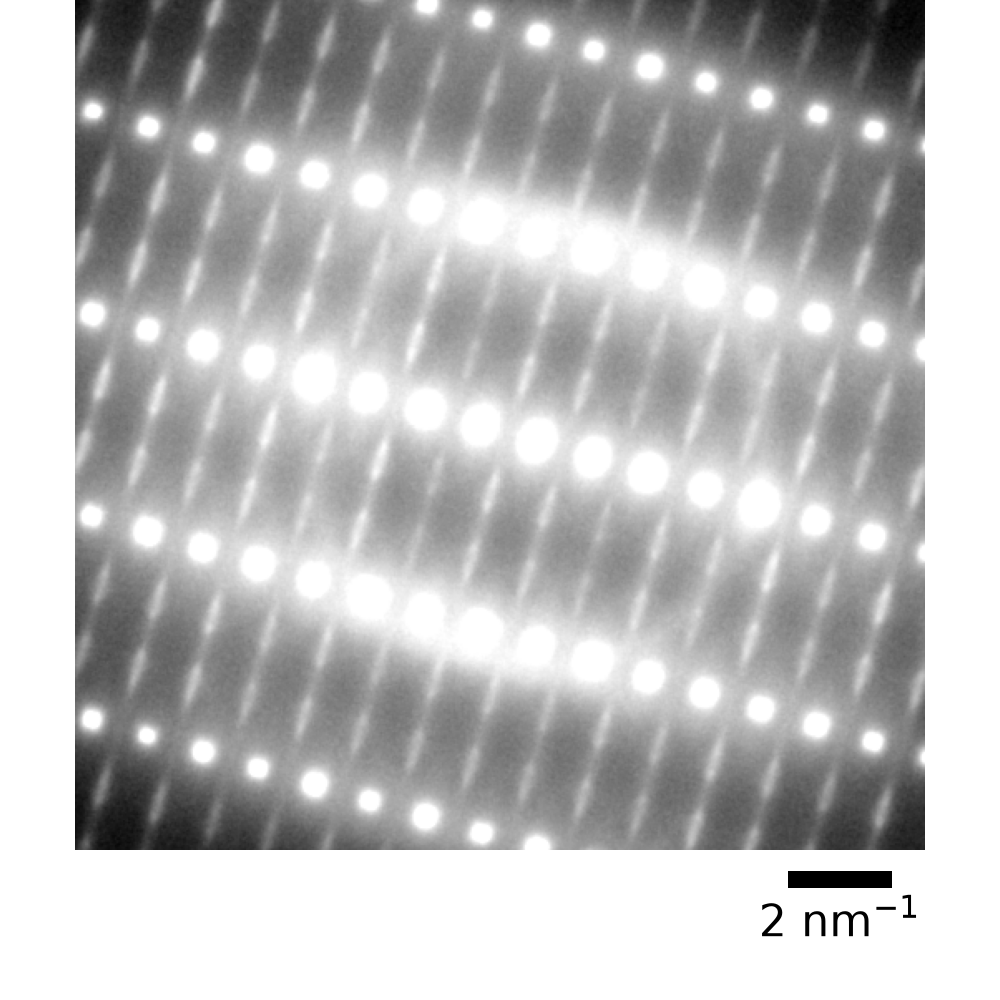

In [14]:
fig = plt.figure(figsize = (10, 10))
fig.subplots_adjust(0, 0, 1, 1)
saplt.PlotDiff(fig, gaussian_filter(dp, 0.5), dq, cmap = 'gray', vmax = np.percentile(dp, 94))
#plt.savefig(os.path.join(work_dir, "diff_plot.svg"), dpi = 300, pad_inches = 0, transparent = True)

# Center the diffraction pattern

In [15]:
#dp_centered = gaussian_filter(dp, 0.5)#.data[265-230:265+230, 278- 230: 278+230]
dp_centered = dp.data[265-230:265+230, 278- 230: 278+230]

# Find Bragg Reflections

In [16]:
peaks = peak_local_max(dp_centered, min_distance = 5, threshold_rel = 0.005, exclude_border = False)
#peaks = np.load(os.path.join(work_dir, "Bragg Peaks.npy"))

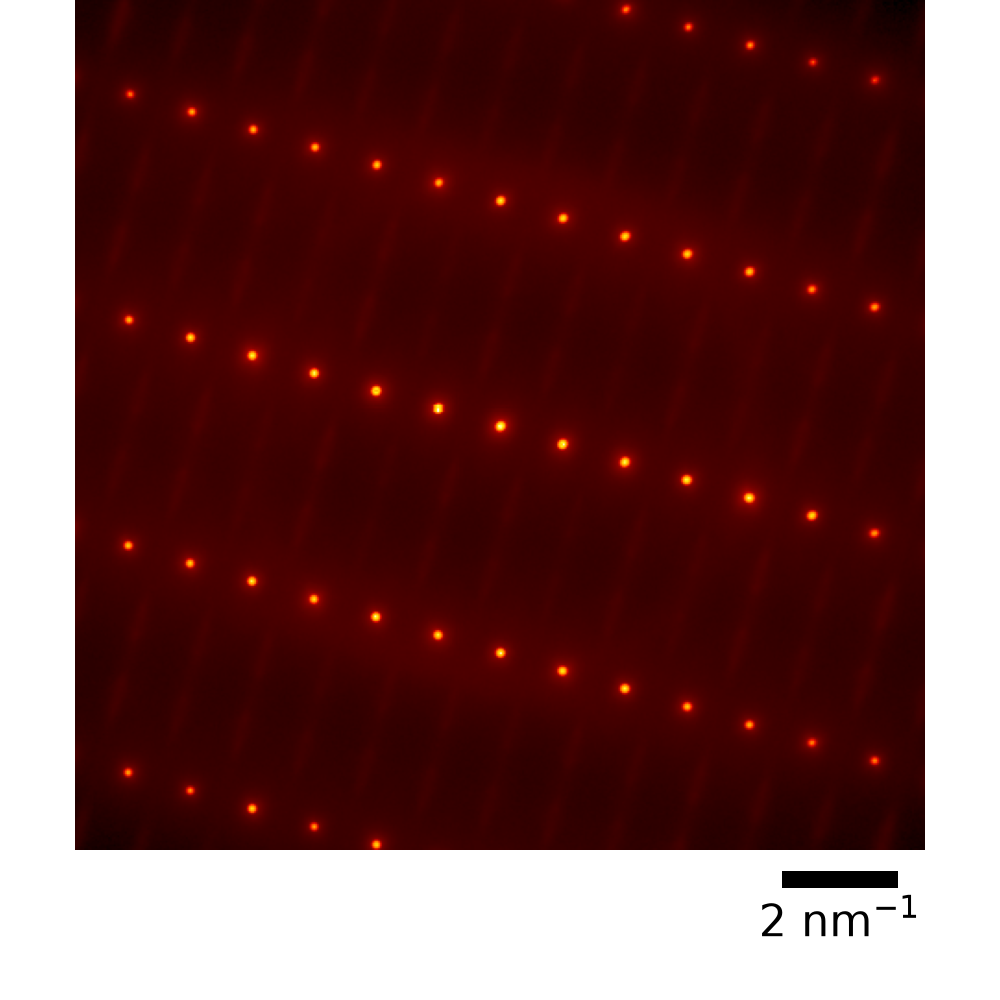

/var/folders/ln/_4p49x493sl51gvfsrdld5640000gn/T/ipykernel_89783/3807138280.py:5: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter(peaks[:, 1], peaks[:, 0], s = 100, c = 'b', marker = 'o', facecolors = 'none', linewidths = 2)


In [17]:
fig = plt.figure(figsize = (10, 10))
fig.subplots_adjust(0, 0, 1, 1)
saplt.PlotDiff(fig, dp_centered, dq)
ax = plt.gca()
ax.scatter(peaks[:, 1], peaks[:, 0], s = 100, c = 'b', marker = 'o', facecolors = 'none', linewidths = 2)

# Punch and Fill to remove Bragg Reflections

In [18]:
def PunchAndFill(dp, peaks, radius):
    rr, cc = np.mgrid[0:dp.shape[0], 0:dp.shape[1]]
    punched = dp.copy().astype(np.float64)
    for peak in peaks:
        mask = (rr - peak[0])**2 + (cc - peak[1])**2 < radius**2
        punched[mask] = np.nan

    target_coords = np.column_stack((rr.ravel(), cc.ravel()))
    valid_mask = ~np.isnan(punched)
    coords = np.column_stack((rr[valid_mask], cc[valid_mask]))
    values = punched[valid_mask]

    missing_mask = ~valid_mask
    missing_coords = np.column_stack((rr[missing_mask], cc[missing_mask]))

    rbf = RBFInterpolator(
        coords,
        values,
        kernel='multiquadric',
        epsilon=2.5,
        smoothing=2.5,
        neighbors=50
    )

    punched_rbf = punched.copy()
    punched_rbf[missing_mask] = rbf(missing_coords)
    
    return punched_rbf
    

    

In [19]:
punched = PunchAndFill(dp_centered, peaks, 15)

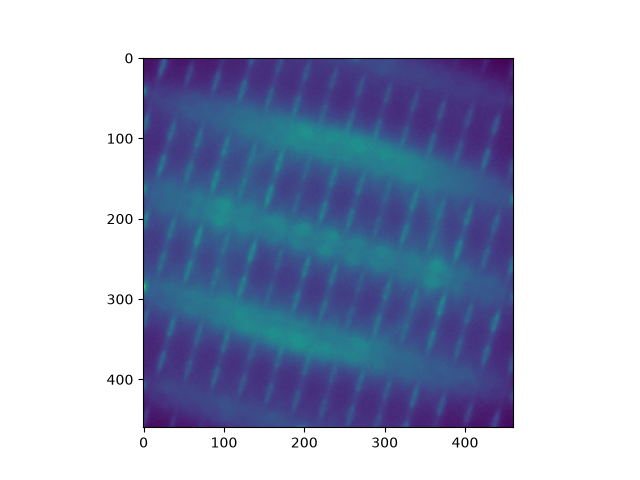

In [20]:
plt.figure()
plt.imshow(punched)

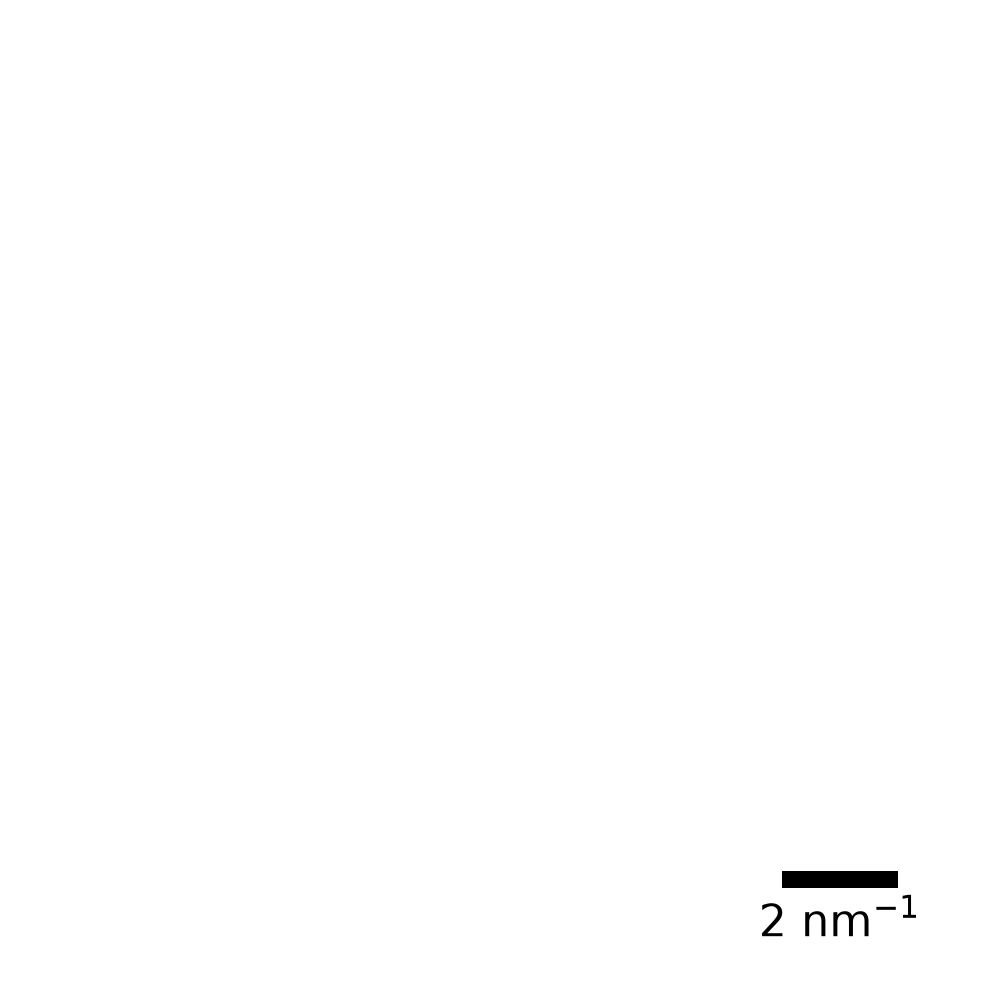

In [21]:
fig = plt.figure(figsize = (10, 10))
saplt.PlotDiff(fig, punched, dq, cmap = 'gray', vmin = 1e-9, vmax = 1e-5)

In [22]:
w = window('hann', punched.shape)

In [23]:
dp_diffuse_pad = np.pad(punched*w, 
                        ((punched.shape[0]//2, punched.shape[0]//2), 
                       (punched.shape[1]//2, punched.shape[1]//2)), 
                      mode='constant')

In [78]:
dpdf = np.fft.ifftshift(np.fft.ifft2(np.fft.fftshift(dp_diffuse_pad)))

In [79]:
dr = 1/(dq*dp_diffuse_pad.shape[0])

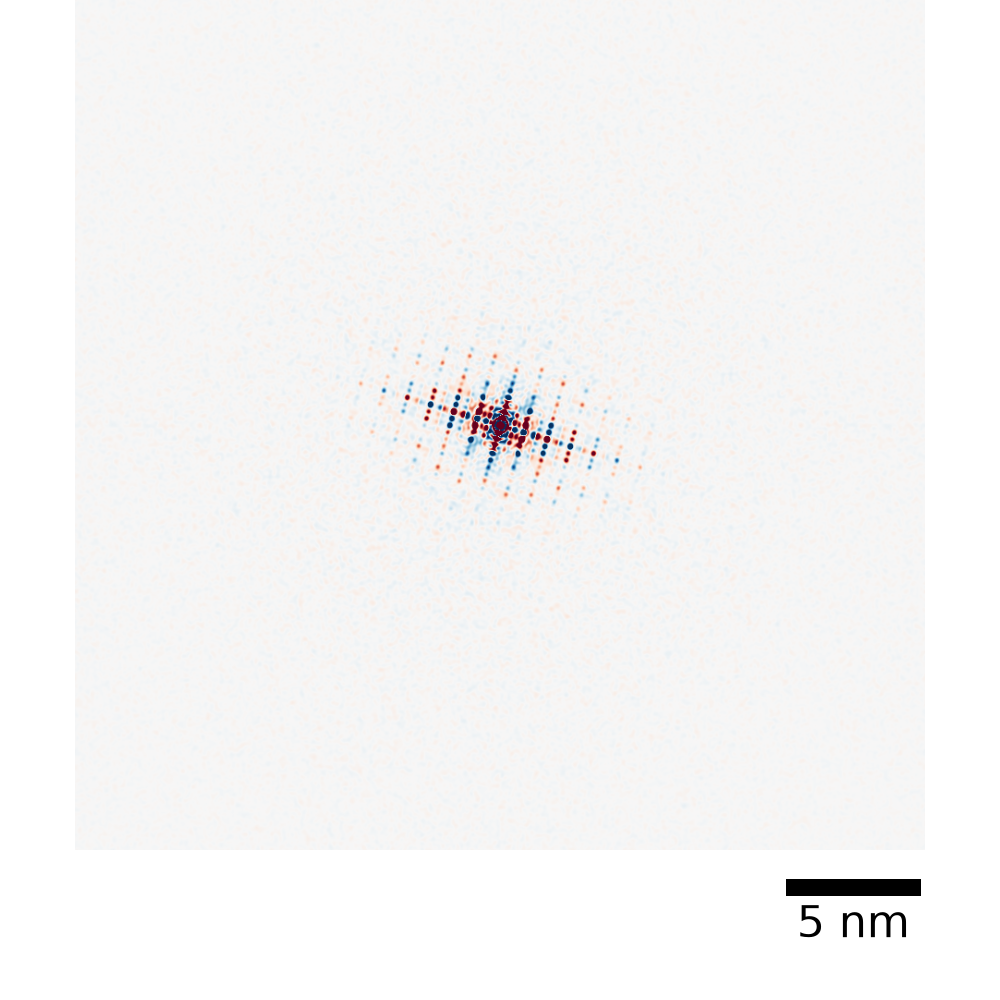

In [81]:
fig = plt.figure(figsize = (10, 10))
fig.subplots_adjust(0, 0, 1, 1)
saplt.PlotImage(fig, dpdf.real, dr, cmap = 'RdBu_r', vmin = -1e2, vmax = 1e2)

# Plotting

In [27]:
delta_pdf_rot = rotate(dpdf.real, 16.5-90, reshape = False)[punched.shape[0] - 230: punched.shape[0] + 230, 
                                                            punched.shape[1] - 230: punched.shape[1] + 230]

#delta_pdf_rot = dpdf.real

In [28]:
def PlotDeltaPDF(fig, delta_pdf_rot, dr, cmap = 'RdBu_r', vmin = None, vmax = None, plot_lattice = False, lattice_dist = None, lattice_range = None):
    ax = fig.add_subplot(111)

    if vmin == None:
        vmin = delta_pdf_rot.min()
    if vmax == None:
        vmax = delta_pdf_rot.max()

    ax.imshow(delta_pdf_rot, cmap=cmap, vmin=vmin, vmax=vmax)

    scalebar = ScaleBar(dr, 
                                    "nm",
                                    dimension = "si-length",
                                    location = 'lower right',
                                    frameon = False,
                                    length_fraction = 0.25,    
                                    height_fraction = 0.02,
                                    bbox_to_anchor=(1, -0.12),
                                    bbox_transform =ax.transAxes,
                                    font_properties = {'size': 32},)
    ax.add_artist(scalebar)

    return ax

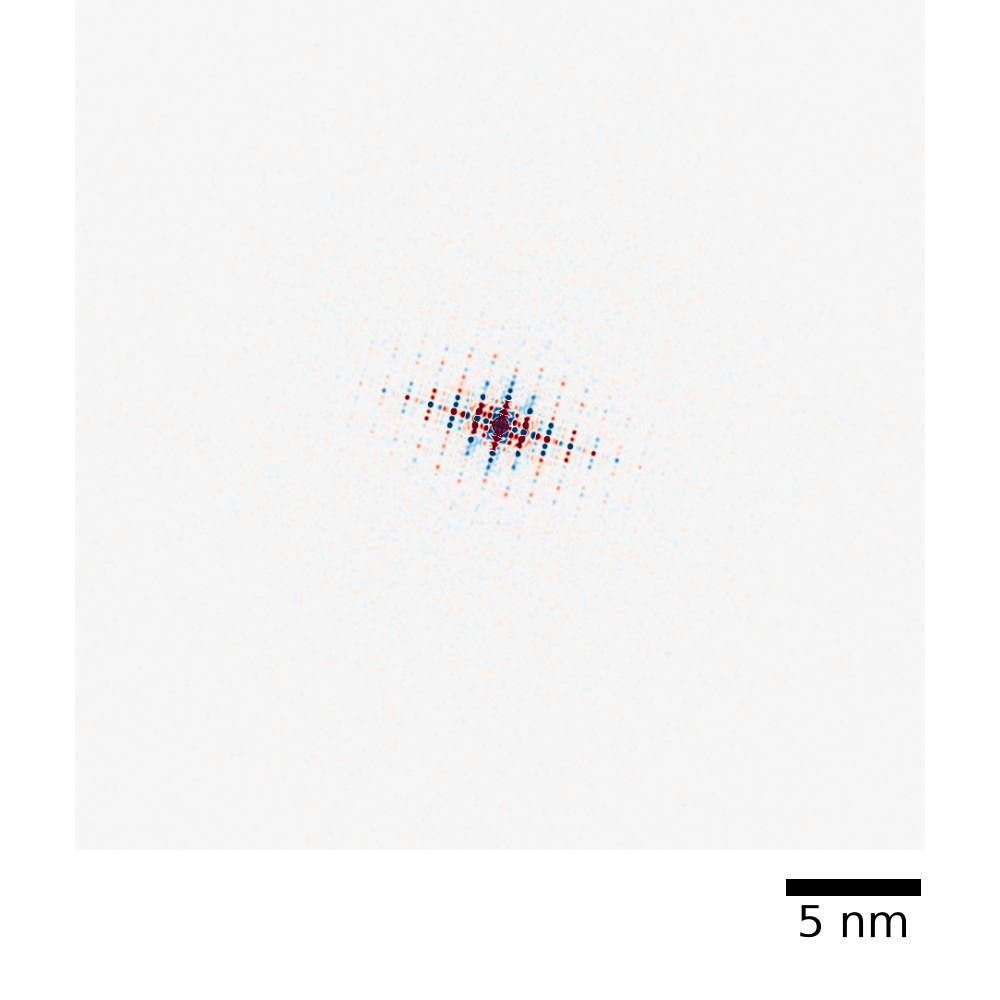

In [29]:
fig = plt.figure(figsize = (10, 10))
fig.subplots_adjust(0, 0, 1, 1)
saplt.PlotImage(fig, dpdf.real, dr, cmap = 'RdBu_r', vmin = -1e8, vmax = 1e8)

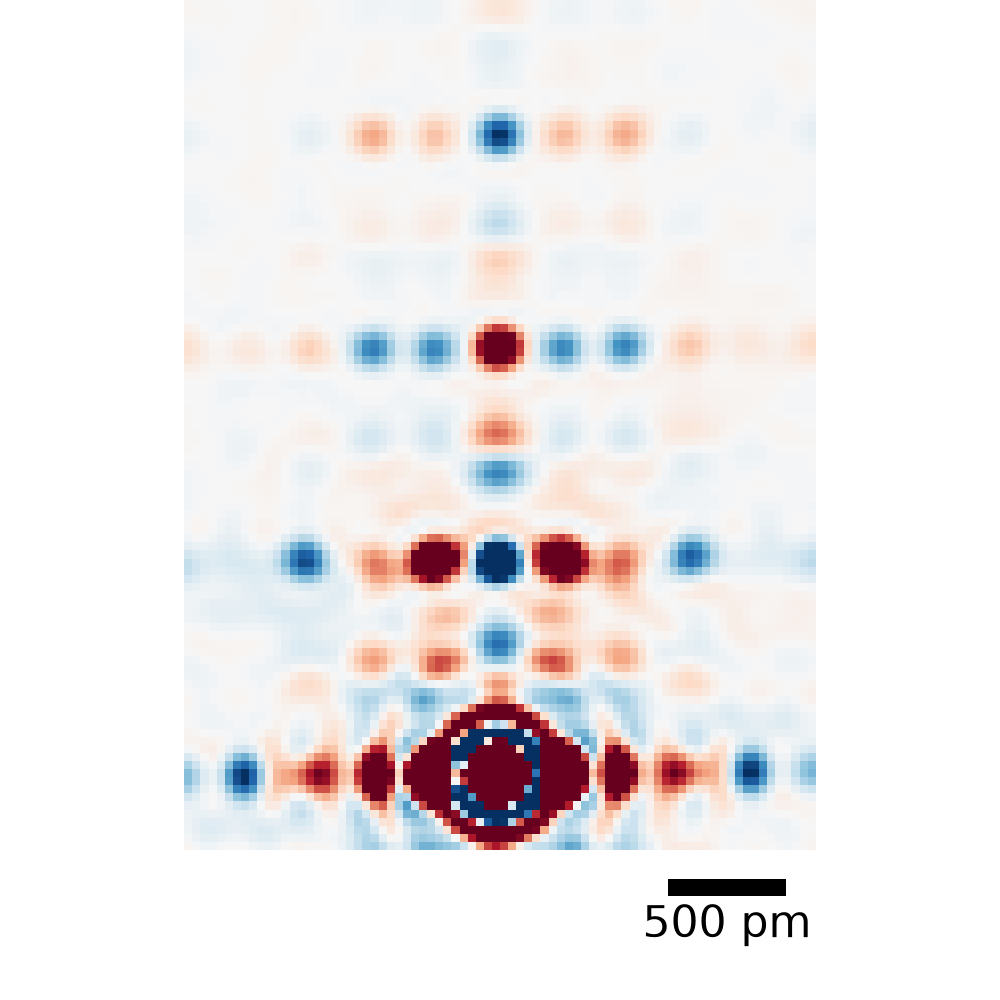

In [ ]:
fig = plt.figure(figsize = (10, 10))
saplt.PlotImage(fig, delta_pdf_rot[delta_pdf_rot.shape[0]//2 - 95 : delta_pdf_rot.shape[0]//2 + 10, 
                                   delta_pdf_rot.shape[1]//2 - 39 : delta_pdf_rot.shape[1]//2 + 39], dr, cmap ='RdBu_r',vmax = 3e8, vmin = -3e8)
ax = plt.gca()
ax.axis("on")
ax.grid(visible = True, color = 'k', alpha = 0.5, linewidth = 2)

ax.set_yticks(np.arange(0, 7)[::-1]*26.5/2+16., [0, 0.5, 1, 1.5, 2, 2.5, 3], fontsize = 24)
ax.set_xticks(np.arange(-4, 5, 2)*7.8 + 38.5, [-4, -2, 0, 2, 4], fontsize = 24)

for tick in ax.xaxis.get_major_ticks() + ax.yaxis.get_major_ticks():
    tick.tick1line.set_rasterized(True)
    tick.tick2line.set_rasterized(True)

for gridline in ax.get_xgridlines() + ax.get_ygridlines():
    gridline.set_rasterized(True)

for spine in ax.spines.values():
    spine.set_rasterized(True)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_rasterized(True)


#plt.savefig(os.path.join(work_dir, "Delta_PDF_cropped_labelled_rasterized.svg"), dpi = 300, transparent = True, pad_inches = 0)